In [9]:
import json
import math
import os
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Reset to matplotlib defaults
mpl.rcdefaults()

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
BASE_DIR = os.path.join(REPO_ROOT, 'data', 'ModelPlacement', 'top_k_beam', 'figures')
JSON_DIR = os.path.join(BASE_DIR, '..', 'json')
if not os.path.isdir(JSON_DIR):
    JSON_DIR = os.path.join(os.getcwd(), 'json')  # fallback: json/ next to this notebook
FIG_DIR  = os.path.join(os.getcwd(), 'figures')
os.makedirs(FIG_DIR, exist_ok=True)


# Powers of 2 plus k=3, so the k=1..4 transition (where throughput still
# changes) is visible on the x-axis
TARGET_KS = [1, 2, 3, 4, 8, 16, 32, 64, 128]

# ── Font size config (change these to adjust all at once) ─────────────
FONT_LABEL    = 20   # x-axis, y-axis label
FONT_TICK     = 18   # tick numbers
FONT_LEGEND   = 18   # legend text
FONT_MARKER   = 8    # marker size
LINE_WIDTH    = 1.8  # line width
FIG_W, FIG_H  = 5.5, 3.5  # single figure size


def find_json(pattern):
    """Find a JSON file matching a glob pattern in JSON_DIR. Returns path or None."""
    matches = glob.glob(os.path.join(JSON_DIR, pattern))
    return matches[0] if matches else None

In [10]:
# ── Data loading ──────────────────────────────────────────────────────

def load_results(filepath):
    """Load JSON and return list of result dicts, sorted by top_k."""
    with open(filepath) as f:
        data = json.load(f)
    return sorted(data['results'], key=lambda r: r['top_k'])


def extract_series(results, model_key):
    """Extract (k_values, times, throughputs) for a specific model, filtered to TARGET_KS."""
    subset = [r for r in results if r['model'] == model_key and 'error' not in r]
    subset.sort(key=lambda r: r['top_k'])
    subset = [r for r in subset if r['top_k'] in TARGET_KS]
    ks    = [r['top_k'] for r in subset]
    times = [r['wall_time_sec'] for r in subset]
    thrs  = [math.ceil(r['total_throughput_rps'] * 100) / 100 for r in subset]
    return ks, times, thrs


# ── Evaluation Cluster ────────────────────────────────────────────────
eval_file = find_json('results_m=*_c=eval_cluster_k=*.json')

if eval_file:
    eval_results = load_results(eval_file)
    eval_llama_k, eval_llama_t, eval_llama_thr = extract_series(eval_results, 'llama3-70b')
    eval_qwen_k,  eval_qwen_t,  eval_qwen_thr  = extract_series(eval_results, 'qwen3-32b')
    print(f"Eval:  {os.path.basename(eval_file)}")
    print(f"  LLaMA k={eval_llama_k}, thr={eval_llama_thr}")
    print(f"  Qwen  k={eval_qwen_k},  thr={eval_qwen_thr}")
else:
    print('Eval cluster JSON not found — subplot (a) will be empty.')
    eval_llama_k = eval_llama_t = eval_llama_thr = []
    eval_qwen_k  = eval_qwen_t  = eval_qwen_thr  = []

# ── Large Cluster ────────────────────────────────────────────────────
large_file = find_json('results_m=*_c=large_hetero_cluster_k=*.json')

if large_file:
    large_results = load_results(large_file)
    large_llama_k, large_llama_t, large_llama_thr = extract_series(large_results, 'llama3-70b')
    large_qwen_k,  large_qwen_t,  large_qwen_thr  = extract_series(large_results, 'qwen3-32b')
    print(f"Large: {os.path.basename(large_file)}")
    print(f"  LLaMA k={large_llama_k}, thr={large_llama_thr}")
    print(f"  Qwen  k={large_qwen_k},  thr={large_qwen_thr}")
else:
    print('Large cluster JSON not found — subplot (b) will be empty.')
    large_llama_k = large_llama_t = large_llama_thr = []
    large_qwen_k  = large_qwen_t  = large_qwen_thr  = []

Eval:  results_m=llama3-70b+qwen3-32b_c=eval_cluster_k=1-128.json
  LLaMA k=[1, 2, 3, 4, 8, 16, 32, 64, 128], thr=[2.39, 2.59, 2.84, 2.84, 2.84, 2.84, 2.84, 2.84, 2.84]
  Qwen  k=[1, 2, 3, 4, 8, 16, 32, 64, 128],  thr=[9.43, 9.43, 9.43, 9.43, 9.43, 9.43, 9.43, 9.43, 9.43]
Large: results_m=llama3-70b+qwen3-32b_c=large_hetero_cluster_k=1-32.json
  LLaMA k=[1, 2, 3, 4, 8, 16, 32], thr=[112.6, 112.58, 112.59, 112.62, 112.65, 112.66, 112.66]
  Qwen  k=[1, 2, 3, 4, 8, 16, 32],  thr=[212.36, 212.3, 212.3, 212.3, 212.3, 212.3, 212.3]


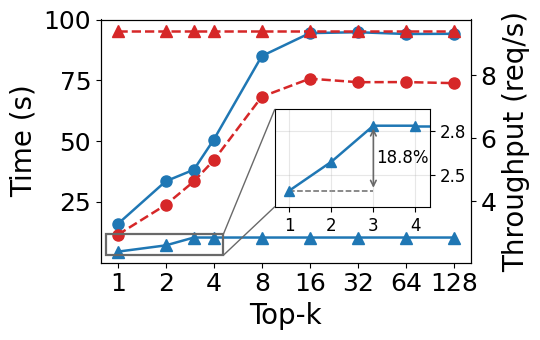

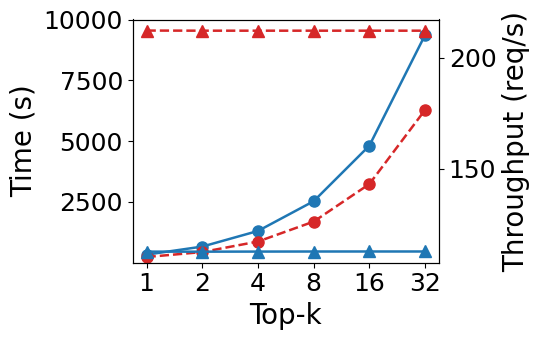

In [11]:
# ── Plotting ──────────────────────────────────────────────────────────
import matplotlib.ticker as ticker
from matplotlib.patches import ConnectionPatch

# Two independent visual dimensions:
#   model  -> color + line style (Llama = blue solid, Qwen = red dashed)
#   metric -> marker             (Time = circle, Throughput = triangle)
COLOR_LLAMA = 'tab:blue'
COLOR_QWEN  = 'tab:red'
MODEL_STYLES = {
    'llama3-70b': {'ls': '-',  'color': COLOR_LLAMA, 'label': 'Llama3-70B'},
    'qwen3-32b':  {'ls': '--', 'color': COLOR_QWEN,  'label': 'Qwen3-32B'},
}
METRIC_MARKERS = {
    'time': 'o',
    'thr':  '^',
}


def plot_single(ax, llama_k, llama_t, llama_thr,
                qwen_k, qwen_t, qwen_thr, time_yticks=None, exclude_ks=()):
    """Draw one cluster figure with dual y-axes. X-axis log2, Time y-axis log."""
    ax2 = ax.twinx()

    lines = []
    labels = []
    has_data = False

    for mk, ks, ts, thrs in [
        ('llama3-70b', llama_k, llama_t, llama_thr),
        ('qwen3-32b',  qwen_k,  qwen_t,  qwen_thr),
    ]:
        if exclude_ks:
            kept = [(k, t, th) for k, t, th in zip(ks, ts, thrs) if k not in exclude_ks]
            ks, ts, thrs = ([list(x) for x in zip(*kept)] if kept else ([], [], []))
        if not ks:
            continue
        has_data = True
        s = MODEL_STYLES[mk]

        l1, = ax.plot(ks, ts, color=s['color'], linestyle=s['ls'],
                      marker=METRIC_MARKERS['time'], markersize=FONT_MARKER, linewidth=LINE_WIDTH,
                      label=f"{s['label']} Time")
        l2, = ax2.plot(ks, thrs, color=s['color'], linestyle=s['ls'],
                       marker=METRIC_MARKERS['thr'], markersize=FONT_MARKER, linewidth=LINE_WIDTH,
                       label=f"{s['label']} Throughput")
        lines.extend([l1, l2])
        labels.extend([l1.get_label(), l2.get_label()])

    ref_k = llama_k if llama_k else qwen_k
    ax.set_xscale('log', base=2)
    # Tick only powers of 2 (k=3 stays as an unlabeled data point;
    # the inset provides the detailed 1..4 view)
    xticks = [k for k in ref_k if k != 3]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(k) for k in xticks], fontsize=FONT_TICK)
    ax.minorticks_off()

    # Time y-axis: linear (absolute) scale
    if time_yticks is not None:
        ax.set_yticks(time_yticks)
        ax.set_yticklabels([str(int(v)) for v in time_yticks])
    ax.set_ylim(bottom=0)

    ax.set_xlabel('Top-k', fontsize=FONT_LABEL)
    ax.set_ylabel('Time (s)', fontsize=FONT_LABEL)
    ax2.set_ylabel('Throughput (req/s)', fontsize=FONT_LABEL)
    ax.tick_params(axis='y', which='major', labelsize=FONT_TICK)
    ax2.tick_params(axis='y', labelsize=FONT_TICK)

    if not has_data:
        ax.text(0.5, 0.5, 'Data not yet available',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=FONT_LABEL, color='gray', fontstyle='italic')

    return lines, labels, ax2


def add_throughput_inset(ax2, ks, thrs, zoom_ks=(1, 2, 3, 4),
                         rect=(0.47, 0.23, 0.42, 0.40)):
    """Inset zooming into the low-k throughput region, where the placement
    is NOT invariant to k (it changes until the plateau is reached)."""
    pts = [(k, t) for k, t in zip(ks, thrs) if k in zoom_ks]
    if len(pts) < 2:
        return None
    zk, zthr = zip(*pts)

    axins = ax2.inset_axes(rect)
    axins.plot(zk, zthr, color=COLOR_LLAMA, linestyle='-', marker=METRIC_MARKERS['thr'],
               markersize=FONT_MARKER - 1, linewidth=LINE_WIDTH)
    # The plateau continues beyond the zoom window: run the line off the
    # right edge of the inset so it does not look truncated at k=4
    axins.plot([zk[-1], max(zoom_ks) + 0.35], [zthr[-1], zthr[-1]],
               color=COLOR_LLAMA, linestyle='-', linewidth=LINE_WIDTH)
    axins.set_xticks(list(zoom_ks))
    axins.set_xticklabels([str(k) for k in zoom_ks], fontsize=FONT_TICK - 6)
    pad = (max(zthr) - min(zthr)) * 0.25
    axins.set_xlim(min(zoom_ks) - 0.35, max(zoom_ks) + 0.35)
    axins.set_ylim(min(zthr) - pad, max(zthr) + pad)
    axins.yaxis.tick_right()
    axins.tick_params(axis='y', labelsize=FONT_TICK - 6)
    axins.set_yticks([2.5, 2.8])
    axins.set_yticklabels(['2.5', '2.8'])
    axins.grid(alpha=0.3)

    # Annotate the k=1 -> k=3 improvement: dashed baseline at the k=1
    # value, vertical arrow up to the k=3 plateau, label to the right
    vals = dict(pts)
    if 1 in vals and 3 in vals:
        v1, v3 = vals[1], vals[3]
        gain = (v3 - v1) / v1 * 100
        arrow_x = 3
        axins.plot([1, arrow_x], [v1, v1], ls='--', lw=1.1, color='dimgray',
                   zorder=1)
        axins.annotate('', xy=(arrow_x, v3), xytext=(arrow_x, v1),
                       arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.2))
        axins.text(arrow_x + 0.06, (v1 + v3) / 2, f'{gain:.1f}%',
                   ha='left', va='center', fontsize=FONT_TICK - 6,
                   clip_on=False)

    # Rectangle on the parent axes around the zoomed region (no connectors)
    x0, x1 = min(zoom_ks) * 0.85, max(zoom_ks) * 1.15
    y0, y1 = min(zthr) - pad, max(zthr) + pad
    ax2.indicate_inset((x0, y0, x1 - x0, y1 - y0),
                       edgecolor='dimgray', alpha=1.0, linewidth=1.6)
    for corner_y, inset_xy in [(y1, (0, 1)), (y0, (0, 0))]:
        con = ConnectionPatch(xyA=(x1, corner_y), coordsA='data', axesA=ax2,
                              xyB=inset_xy, coordsB='axes fraction', axesB=axins,
                              color='dimgray', lw=1.0)
        ax2.figure.add_artist(con)
    return axins


# ── (a) Evaluation Cluster ────────────────────────────────────────────
fig_a, ax_a = plt.subplots(1, 1, figsize=(FIG_W, FIG_H))
lines_a, labels_a, ax2_a = plot_single(
    ax_a,
    eval_llama_k, eval_llama_t, eval_llama_thr,
    eval_qwen_k,  eval_qwen_t,  eval_qwen_thr,
    time_yticks=[25, 50, 75, 100],
)
add_throughput_inset(ax2_a, eval_llama_k, eval_llama_thr)
fig_a.tight_layout()
fig_a.savefig(os.path.join(FIG_DIR, 'top_k_dp_result_evaluation_cluster.pdf'), bbox_inches='tight', dpi=300)
fig_a.savefig(os.path.join(FIG_DIR, 'top_k_dp_result_evaluation_cluster.png'), bbox_inches='tight', dpi=300)
plt.show()

# ── (b) Large Cluster ────────────────────────────────────────────────
fig_b, ax_b = plt.subplots(1, 1, figsize=(FIG_W, FIG_H))
lines_b, labels_b, ax2_b = plot_single(
    ax_b,
    large_llama_k, large_llama_t, large_llama_thr,
    large_qwen_k,  large_qwen_t,  large_qwen_thr,
    time_yticks=[2500, 5000, 7500, 10000],
    exclude_ks=(3,),
)
fig_b.tight_layout()
fig_b.savefig(os.path.join(FIG_DIR, 'top_k_dp_result_large_cluster.pdf'), bbox_inches='tight', dpi=300)
fig_b.savefig(os.path.join(FIG_DIR, 'top_k_dp_result_large_cluster.png'), bbox_inches='tight', dpi=300)
plt.show()

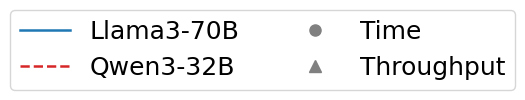

Saved: top_k_dp_result_evaluation_cluster, top_k_dp_result_large_cluster, top_k_legend


In [12]:
# ── Legend (separate file + display) ──────────────────────────────────
# Two independent dimensions, shown as two columns (column-major fill):
#   column 1 -> model:  blue solid Llama / red dashed Qwen (color + line style)
#   column 2 -> metric: circle Time / triangle Throughput (marker, neutral gray)
from matplotlib.lines import Line2D

model_handles = [
    Line2D([0], [0], color=MODEL_STYLES['llama3-70b']['color'],
           linestyle=MODEL_STYLES['llama3-70b']['ls'], linewidth=LINE_WIDTH,
           label=MODEL_STYLES['llama3-70b']['label']),
    Line2D([0], [0], color=MODEL_STYLES['qwen3-32b']['color'],
           linestyle=MODEL_STYLES['qwen3-32b']['ls'], linewidth=LINE_WIDTH,
           label=MODEL_STYLES['qwen3-32b']['label']),
]
metric_handles = [
    Line2D([0], [0], color='gray', linestyle='None', marker=METRIC_MARKERS['time'],
           markersize=FONT_MARKER, label='Time'),
    Line2D([0], [0], color='gray', linestyle='None', marker=METRIC_MARKERS['thr'],
           markersize=FONT_MARKER, label='Throughput'),
]
# Column-major fill with ncol=2 -> col 1 = models, col 2 = metrics
all_lines  = model_handles + metric_handles
all_labels = [h.get_label() for h in all_lines]

fig_leg, ax_leg = plt.subplots(1, 1, figsize=(6, 0.8))
ax_leg.axis('off')
ax_leg.legend(all_lines, all_labels, loc='center', ncol=2, frameon=True, fontsize=FONT_LEGEND)
fig_leg.savefig(os.path.join(FIG_DIR, 'top_k_legend.pdf'), bbox_inches='tight', dpi=300)
fig_leg.savefig(os.path.join(FIG_DIR, 'top_k_legend.png'), bbox_inches='tight', dpi=300)
plt.show()

print(f'Saved: top_k_dp_result_evaluation_cluster, top_k_dp_result_large_cluster, top_k_legend')